In [1]:
## TO RUN ON THE CLOUD 

## preprocessed the data before starting the slide
## import embeddings <s
import os

# Define the URI to point to your manual process
os.environ["FIFTYONE_DATABASE_URI"] = "mongodb://localhost:44123"

import fiftyone as fo

# Verify connection
print(fo.core.odm.database.get_db_conn()) 


You are running the oldest supported major version of MongoDB. Please refer to https://deprecation.voxel51.com for deprecation notices. You can suppress this exception by setting your `database_validation` config parameter to `False`. See https://docs.voxel51.com/user_guide/config.html#configuring-a-mongodb-connection for more information
Database(MongoClient(host=['localhost:44123'], document_class=dict, tz_aware=False, connect=True, appname='fiftyone'), 'fiftyone')


In [2]:
import fiftyone as fo

## list all dataset
print(fo.list_datasets())

# Close any zombie sessions that might be hanging
fo.close_app()

['FLPLAN', 'dugong', 'flplan200', 'flplanpatches']


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


### Audit ground truth

In [15]:
import fiftyone as fo
from pathlib import Path

def parse_label_line(line: str):
    """
    Parse one line from a labels/ annotation file.
    
    Format: x1 y1 x2 y2 label [extra fields...]
    Example: 1596 2776 1638 2910 Dugong 154 none
    
    Returns (x1, y1, x2, y2, label_str) or None if unparseable.
    """
    parts = line.strip().split()
    if len(parts) < 5:
        return None
    try:
        x1    = float(parts[0])
        y1    = float(parts[1])
        x2    = float(parts[2])
        y2    = float(parts[3])
        label = parts[4]
        return x1, y1, x2, y2, label
    except ValueError:
        return None


def build_audit_detections(
    label_path: Path,
    img_w: int,
    img_h: int,
) -> fo.Detections:
    """
    Read a label file and return a fo.Detections object
    with bounding boxes normalised to [0,1].
    """
    if not label_path.exists():
        return fo.Detections(detections=[])

    detections = []
    for line in label_path.read_text().splitlines():
        line = line.strip()
        if not line:
            continue

        parsed = parse_label_line(line)
        if parsed is None:
            print(f"  WARN could not parse line: '{line}' in {label_path.name}")
            continue

        x1, y1, x2, y2, label = parsed

        # sanity check — coordinates should be within image bounds
        if x2 <= x1 or y2 <= y1:
            print(f"  WARN degenerate box [{x1},{y1},{x2},{y2}] in {label_path.name}")
            continue

        # convert absolute xyxy → normalised xywh (FiftyOne format)
        x_norm = x1 / img_w
        y_norm = y1 / img_h
        w_norm = (x2 - x1) / img_w
        h_norm = (y2 - y1) / img_h

        # clamp to [0, 1] for safety
        x_norm = max(0.0, min(x_norm, 1.0))
        y_norm = max(0.0, min(y_norm, 1.0))
        w_norm = max(0.0, min(w_norm, 1.0 - x_norm))
        h_norm = max(0.0, min(h_norm, 1.0 - y_norm))

        detections.append(
            fo.Detection(
                label        = label.lower(),   # normalise to lowercase
                bounding_box = [x_norm, y_norm, w_norm, h_norm],
            )
        )

    return fo.Detections(detections=detections)



In [16]:

# ── Main audit loop ───────────────────────────────────────────────────────────

n_ok      = 0
n_missing = 0
n_empty   = 0
n_error   = 0

for sample in dataset.iter_samples(autosave=True, progress=True):

    # derive the label file path from the image filepath
    # structure: .../images/{stem}.jpg  →  .../labels/{stem}.txt
    image_path  = Path(sample.filepath)
    label_path  = image_path.parent.parent / "labels" / image_path.with_suffix(".txt").name

    # get image dimensions from metadata
    if sample.metadata is None:
        print(f"  WARN no metadata for {image_path.name} — skipping")
        n_error += 1
        continue

    img_w = sample.metadata.width
    img_h = sample.metadata.height

    if img_w is None or img_h is None:
        print(f"  WARN metadata has no width/height for {image_path.name} — skipping")
        n_error += 1
        continue

    # build detections
    if not label_path.exists():
        sample["ground_truth"] = fo.Detections(detections=[])
        n_missing += 1
        continue

    audit_dets = build_audit_detections(label_path, img_w, img_h)
    sample["ground_truth"] = audit_dets

    if len(audit_dets.detections) == 0:
        n_empty += 1
    else:
        n_ok += 1

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\nAudit complete:")
print(f"  samples with detections : {n_ok}")
print(f"  samples with empty file : {n_empty}")
print(f"  label file not found    : {n_missing}")
print(f"  skipped (no metadata)   : {n_error}")

  12% |██|----------------| 10/83 [884.4ms elapsed, 6.5s remaining, 11.3 samples/s] 

 100% |███████████████████| 83/83 [4.5s elapsed, 0s remaining, 18.6 samples/s]      

Audit complete:
  samples with detections : 83
  samples with empty file : 0
  label file not found    : 0
  skipped (no metadata)   : 0


# Evaluate

In [10]:
session.refresh()

In [4]:
import sys
%load_ext autoreload
%autoreload 2

# import sys
# sys.path.append("/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src")


In [10]:
import sys
from pathlib import Path

project_root = Path.cwd().parent 
sys.path.append(str(project_root / "src"))


In [4]:
dataset = fo.load_dataset("FLPLAN")

#### query the inference folder

In [ ]:
from src.manage_fiftyone import query_inference_jsons, add_prediction_fields, remove_prediction_fields

inference_folder = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan"
list_inferences = query_inference_jsons(
    inference_folder,
    seed='seed0',
)

remove_prediction_fields(
    dataset,
    seed="seed2",
    include_nms=True,
    dry_run=False
)

In [15]:
inference_folder = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan"
list_inferences = query_inference_jsons(
    inference_folder,
    seed='seed0',
)

  Found 45 JSON files in 'inference_flplan'
  Matched 15 / 45 files
    NWW_p100_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p100_random_seed0_rtdetr_0606_1050_test_predictions.json
    NWW_p10_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p10_random_seed0_rtdetr_0606_1048_test_predictions.json
    NWW_p20_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p20_random_seed0_rtdetr_0606_1049_test_predictions.json
    NWW_p30_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p30_random_seed0_rtdetr_0606_1049_test_predictions.json
    NWW_p40_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p40_random_seed0_rtdetr_0606_1049_test_predictions.json
    NWW_p50_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p50_random_seed0_rtdetr_0606_1050_test_predictions.json
    NWW_p5_aclr_seed0_rtdetr_0606_1045_test_predictions.json
    NWW_p5_random_seed0_rtdetr_0606_1045_test_predictions.json
    baseline_seed0_test_predictions.json


In [18]:
remove_prediction_fields(
    dataset,
    seed="seed2",
    include_nms=True,
    dry_run=False
)


  DELETING 30 fields:
    NWW_p100_aclr_seed2_nms
    NWW_p100_aclr_seed2_raw
    NWW_p100_random_seed2_nms
    NWW_p100_random_seed2_raw
    NWW_p10_aclr_seed2_nms
    NWW_p10_aclr_seed2_raw
    NWW_p10_random_seed2_nms
    NWW_p10_random_seed2_raw
    NWW_p20_aclr_seed2_nms
    NWW_p20_aclr_seed2_raw
    NWW_p20_random_seed2_nms
    NWW_p20_random_seed2_raw
    NWW_p30_aclr_seed2_nms
    NWW_p30_aclr_seed2_raw
    NWW_p30_random_seed2_nms
    NWW_p30_random_seed2_raw
    NWW_p40_aclr_seed2_nms
    NWW_p40_aclr_seed2_raw
    NWW_p40_random_seed2_nms
    NWW_p40_random_seed2_raw
    NWW_p50_aclr_seed2_nms
    NWW_p50_aclr_seed2_raw
    NWW_p50_random_seed2_nms
    NWW_p50_random_seed2_raw
    NWW_p5_aclr_seed2_nms
    NWW_p5_aclr_seed2_raw
    NWW_p5_random_seed2_nms
    NWW_p5_random_seed2_raw
    baseline_seed2_nms
    baseline_seed2_raw


  deleted  NWW_p100_aclr_seed2_nms
  deleted  NWW_p100_aclr_seed2_raw
  deleted  NWW_p100_random_seed2_nms
  deleted  NWW_p100_random_seed2_raw
  deleted  NWW_p10_aclr_seed2_nms
  deleted  NWW_p10_aclr_seed2_raw
  deleted  NWW_p10_random_seed2_nms
  deleted  NWW_p10_random_seed2_raw
  deleted  NWW_p20_aclr_seed2_nms
  deleted  NWW_p20_aclr_seed2_raw
  deleted  NWW_p20_random_seed2_nms
  deleted  NWW_p20_random_seed2_raw
  deleted  NWW_p30_aclr_seed2_nms
  deleted  NWW_p30_aclr_seed2_raw
  deleted  NWW_p30_random_seed2_nms
  deleted  NWW_p30_random_seed2_raw
  deleted  NWW_p40_aclr_seed2_nms
  deleted  NWW_p40_aclr_seed2_raw
  deleted  NWW_p40_random_seed2_nms
  deleted  NWW_p40_random_seed2_raw
  deleted  NWW_p50_aclr_seed2_nms
  deleted  NWW_p50_aclr_seed2_raw
  deleted  NWW_p50_random_seed2_nms
  deleted  NWW_p50_random_seed2_raw
  deleted  NWW_p5_aclr_seed2_nms
  deleted  NWW_p5_aclr_seed2_raw
  deleted  NWW_p5_random_seed2_nms
  deleted  NWW_p5_random_seed2_raw
  deleted  baseline_

['NWW_p100_aclr_seed2_nms',
 'NWW_p100_aclr_seed2_raw',
 'NWW_p100_random_seed2_nms',
 'NWW_p100_random_seed2_raw',
 'NWW_p10_aclr_seed2_nms',
 'NWW_p10_aclr_seed2_raw',
 'NWW_p10_random_seed2_nms',
 'NWW_p10_random_seed2_raw',
 'NWW_p20_aclr_seed2_nms',
 'NWW_p20_aclr_seed2_raw',
 'NWW_p20_random_seed2_nms',
 'NWW_p20_random_seed2_raw',
 'NWW_p30_aclr_seed2_nms',
 'NWW_p30_aclr_seed2_raw',
 'NWW_p30_random_seed2_nms',
 'NWW_p30_random_seed2_raw',
 'NWW_p40_aclr_seed2_nms',
 'NWW_p40_aclr_seed2_raw',
 'NWW_p40_random_seed2_nms',
 'NWW_p40_random_seed2_raw',
 'NWW_p50_aclr_seed2_nms',
 'NWW_p50_aclr_seed2_raw',
 'NWW_p50_random_seed2_nms',
 'NWW_p50_random_seed2_raw',
 'NWW_p5_aclr_seed2_nms',
 'NWW_p5_aclr_seed2_raw',
 'NWW_p5_random_seed2_nms',
 'NWW_p5_random_seed2_raw',
 'baseline_seed2_nms',
 'baseline_seed2_raw']

In [11]:
from fiftyone import StringField
from fiftyone import ViewField as F

# ── Define which fields to convert and their prefix ──────────────────────────
FLOAT_TO_STRING = {
    "cluster_label":   "cluster_",
    "cluster_label_8": "cluster_",
}

for field_name, prefix in FLOAT_TO_STRING.items():

    print(f"\nConverting '{field_name}' float → string ...")

    # Step 1 — write new string values to a temp field
    temp_field = f"{field_name}_str_temp"

    for sample in dataset.iter_samples(autosave=True, progress=True):
        val = sample.get_field(field_name)
        if val is not None:
            sample[temp_field] = f"{prefix}{int(val)}"
        else:
            sample[temp_field] = None

    # Step 2 — verify the temp field looks right before committing
    print(f"  temp field unique values: {sorted(dataset.distinct(temp_field))}")
    print(f"  sample count with None  : {dataset.match(F(temp_field) == None).count()}")

    confirm = input(f"  Looks good? Overwrite '{field_name}' with temp values? [y/n]: ")
    if confirm.strip().lower() != "y":
        dataset.delete_sample_field(temp_field)
        print(f"  Aborted — temp field deleted.")
        continue

    # Step 3 — delete the original float field and rename temp to original name
    dataset.delete_sample_field(field_name)
    dataset.rename_sample_field(temp_field, field_name)

    # Step 4 — recreate the index on the new string field
    try:
        dataset.create_index(field_name)
        print(f"  Index recreated on '{field_name}'")
    except Exception as e:
        print(f"  WARN index creation failed: {e}")

    print(f"  Done — '{field_name}' is now a string field")

    # Step 5 — verify
    print(f"  Final unique values: {sorted(dataset.distinct(field_name))}")

dataset.save()
print("\nAll conversions complete.")


Converting 'cluster_label' float → string ...
 100% |███████████████████| 83/83 [2.5s elapsed, 0s remaining, 40.8 samples/s]      
  temp field unique values: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'cluster_9']
  sample count with None  : 0
  Index recreated on 'cluster_label'
  Done — 'cluster_label' is now a string field
  Final unique values: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'cluster_9']

Converting 'cluster_label_8' float → string ...
 100% |███████████████████| 83/83 [3.0s elapsed, 0s remaining, 40.0 samples/s]      
  temp field unique values: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7']
  sample count with None  : 0
  Index recreated on 'cluster_label_8'
  Done — 'cluster_label_8' is now a string field
  Final unique values: ['cluster_0', 'cluster_1', 'clust

In [ ]:
#dataset.delete_sample_fields("ground_truth")

In [7]:
view_test_0 = dataset.load_saved_view('view_test0')
view_test_1= dataset.load_saved_view('view_test1')
view_test_2 = dataset.load_saved_view('view_test2')

In [19]:
all_fields = dataset.get_field_schema().keys()
seed0_fields = [f for f in all_fields if "seed0" in f]
seed0_fields

['NWW_p40_aclr_seed0_raw',
 'NWW_p40_aclr_seed0_nms',
 'NWW_p40_random_seed0_raw',
 'NWW_p40_random_seed0_nms',
 'NWW_p50_random_seed0_raw',
 'NWW_p50_random_seed0_nms',
 'NWW_p10_aclr_seed0_raw',
 'NWW_p10_aclr_seed0_nms',
 'NWW_p5_random_seed0_raw',
 'NWW_p5_random_seed0_nms',
 'NWW_p100_aclr_seed0_raw',
 'NWW_p100_aclr_seed0_nms',
 'NWW_p5_aclr_seed0_raw',
 'NWW_p5_aclr_seed0_nms',
 'NWW_p20_random_seed0_raw',
 'NWW_p20_random_seed0_nms',
 'NWW_p30_random_seed0_raw',
 'NWW_p30_random_seed0_nms',
 'NWW_p10_random_seed0_raw',
 'NWW_p10_random_seed0_nms',
 'NWW_p20_aclr_seed0_raw',
 'NWW_p20_aclr_seed0_nms',
 'NWW_p30_aclr_seed0_raw',
 'NWW_p30_aclr_seed0_nms',
 'NWW_p50_aclr_seed0_raw',
 'NWW_p50_aclr_seed0_nms',
 'NWW_p100_random_seed0_raw',
 'NWW_p100_random_seed0_nms',
 'baseline_seed0_raw',
 'baseline_seed0_nms']

In [20]:
all_fields

odict_keys(['id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modified_at', 'region', 'mission_name', 'parent_name', 'roi_grid', 'full_embeddings', 'full_emb_umap_dinov3', 'flight_mission', 'm_flight', 'uniqueness_score', 'representativeness_score', 'v2_full_emb_umap_dinov3', 'uniqueness_score_per_cluster', 'name_plot', 'soft_coverage_score', 'NWW_p40_aclr_seed0_raw', 'NWW_p40_aclr_seed0_nms', 'NWW_p40_random_seed0_raw', 'NWW_p40_random_seed0_nms', 'NWW_p50_random_seed0_raw', 'NWW_p50_random_seed0_nms', 'NWW_p10_aclr_seed0_raw', 'NWW_p10_aclr_seed0_nms', 'NWW_p5_random_seed0_raw', 'NWW_p5_random_seed0_nms', 'NWW_p100_aclr_seed0_raw', 'NWW_p100_aclr_seed0_nms', 'NWW_p5_aclr_seed0_raw', 'NWW_p5_aclr_seed0_nms', 'NWW_p20_random_seed0_raw', 'NWW_p20_random_seed0_nms', 'NWW_p30_random_seed0_raw', 'NWW_p30_random_seed0_nms', 'NWW_p10_random_seed0_raw', 'NWW_p10_random_seed0_nms', 'NWW_p20_aclr_seed0_raw', 'NWW_p20_aclr_seed0_nms', 'NWW_p30_aclr_seed0_raw', 'NWW_p30_aclr_seed0_nms', '

In [7]:
all_fields = dataset.get_field_schema().keys()
seed0_fields = [f for f in all_fields if "seed0" in f]
seed0_nms_fields = [f for f in seed0_fields if "nms" in f]
seed0_raw_fields = [f for f in seed0_fields if "raw" in f]
seed1_fields = [f for f in all_fields if "seed1" in f]
seed1_nms_fields = [f for f in seed1_fields if "nms" in f]
seed1_raw_fields = [f for f in seed1_fields if "raw" in f]
seed2_fields = [f for f in all_fields if "seed2" in f]
seed2_nms_fields = [f for f in seed2_fields if "nms" in f]
seed2_raw_fields = [f for f in seed2_fields if "raw" in f]
core_fields = [
    'id', 'filepath',"thumbnail_path", 'tags', 'metadata', 'created_at', 'last_modified_at', 'region', 'mission_name', 'parent_name', 'flight_mission', 'm_flight', 'uniqueness_score', 'representativeness_score', 'cluster_label', 'uniqueness_score_per_cluster', 'name_plot', 'cluster_label_8', 'soft_coverage_score',"roi_grid","ground_truth","audit"
]
embeddings_fields = [ 'full_embeddings', 'full_emb_umap_dinov3','v2_full_emb_umap_dinov3'] 


# Everything else goes into a collapsed "other" group
assigned = set(core_fields + seed0_fields + embeddings_fields )
other_fields = [f for f in all_fields if f not in assigned]


dataset.app_config.sidebar_groups = [
    fo.SidebarGroupDocument(name="core",    paths=core_fields,   expanded=True),
    fo.SidebarGroupDocument(name="seed_0_nms",  paths=seed0_nms_fields,  expanded=False),
    fo.SidebarGroupDocument(name="seed_0_raw",  paths=seed0_raw_fields,  expanded=False),
    fo.SidebarGroupDocument(name="seed_1_nms",  paths=seed0_nms_fields,  expanded=False),
    fo.SidebarGroupDocument(name="seed_1_raw",  paths=seed0_raw_fields,  expanded=False),
    fo.SidebarGroupDocument(name="seed_2_nms",  paths=seed0_nms_fields,  expanded=False),
    fo.SidebarGroupDocument(name="seed_2_raw",  paths=seed0_raw_fields,  expanded=False),
    fo.SidebarGroupDocument(name="embeddings", paths=embeddings_fields,  expanded=False),
    fo.SidebarGroupDocument(name="other",   paths=other_fields,   expanded=False),
]
dataset.save()

In [8]:

_EVAL_SUFFIXES = ("_tp", "_fp", "_fn", "_tn", "_iou")

ALWAYS_EXCLUDE = {
    "full_embeddings",
    "full_emb_umap_dinov3",
    "v2_full_emb_umap_dinov3",
   # "roi_grid",
}

all_fields = set(dataset.get_field_schema().keys())

fields_to_load = [
    f for f in all_fields
    if f not in ALWAYS_EXCLUDE
    and not any(f.endswith(s) for s in _EVAL_SUFFIXES)
    and not f.endswith("_raw")   # exclude raw predictions
]

print(f"Loading {len(fields_to_load)} fields:")
for f in sorted(fields_to_load):
    print(f"  {f}")

view = (
    dataset
    .select_fields(fields_to_load)
)

session = fo.launch_app(
    view,
    port=5151,
    auto=False,
)

Loading 67 fields:
  NWW_p100_aclr_seed0_nms
  NWW_p100_aclr_seed1_nms
  NWW_p100_aclr_seed2_nms
  NWW_p100_random_seed0_nms
  NWW_p100_random_seed1_nms
  NWW_p100_random_seed2_nms
  NWW_p10_aclr_seed0_nms
  NWW_p10_aclr_seed1_nms
  NWW_p10_aclr_seed2_nms
  NWW_p10_random_seed0_nms
  NWW_p10_random_seed1_nms
  NWW_p10_random_seed2_nms
  NWW_p20_aclr_seed0_nms
  NWW_p20_aclr_seed1_nms
  NWW_p20_aclr_seed2_nms
  NWW_p20_random_seed0_nms
  NWW_p20_random_seed1_nms
  NWW_p20_random_seed2_nms
  NWW_p30_aclr_seed0_nms
  NWW_p30_aclr_seed1_nms
  NWW_p30_aclr_seed2_nms
  NWW_p30_random_seed0_nms
  NWW_p30_random_seed1_nms
  NWW_p30_random_seed2_nms
  NWW_p40_aclr_seed0_nms
  NWW_p40_aclr_seed1_nms
  NWW_p40_aclr_seed2_nms
  NWW_p40_random_seed0_nms
  NWW_p40_random_seed1_nms
  NWW_p40_random_seed2_nms
  NWW_p50_aclr_seed0_nms
  NWW_p50_aclr_seed1_nms
  NWW_p50_aclr_seed2_nms
  NWW_p50_random_seed0_nms
  NWW_p50_random_seed1_nms
  NWW_p50_random_seed2_nms
  NWW_p5_aclr_seed0_nms
  NWW_p5_aclr_s

In [44]:
dataset

Name:        FLPLAN
Media type:  image
Num samples: 83
Persistent:  True
Tags:        []
Sample fields:
    id:                           fiftyone.core.fields.ObjectIdField
    filepath:                     fiftyone.core.fields.StringField
    tags:                         fiftyone.core.fields.ListField(fiftyone.core.fields.StringField)
    metadata:                     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.metadata.ImageMetadata)
    created_at:                   fiftyone.core.fields.DateTimeField
    last_modified_at:             fiftyone.core.fields.DateTimeField
    region:                       fiftyone.core.fields.StringField
    mission_name:                 fiftyone.core.fields.StringField
    parent_name:                  fiftyone.core.fields.StringField
    roi_grid:                     fiftyone.core.fields.EmbeddedDocumentField(fiftyone.core.labels.Detections)
    full_embeddings:              fiftyone.core.fields.VectorField
    full_emb_umap_dinov3:     

In [40]:
session.refresh()

In [21]:
dataset.app_config.sidebar_groups

[<SidebarGroupDocument: {
     'name': 'core',
     'paths': [
         'id',
         'filepath',
         'tags',
         'metadata',
         'created_at',
         'last_modified_at',
         'region',
         'mission_name',
         'parent_name',
         'full_embeddings',
         'flight_mission',
         'm_flight',
         'uniqueness_score',
         'representativeness_score',
         'cluster_label',
         'uniqueness_score_per_cluster',
         'name_plot',
         'cluster_label_8',
         'soft_coverage_score',
     ],
     'expanded': True,
 }>,
 <SidebarGroupDocument: {
     'name': 'seed_0_nms',
     'paths': [
         'NWW_p40_aclr_seed0_nms',
         'NWW_p40_random_seed0_nms',
         'NWW_p50_random_seed0_nms',
         'NWW_p10_aclr_seed0_nms',
         'NWW_p5_random_seed0_nms',
         'NWW_p100_aclr_seed0_nms',
         'NWW_p5_aclr_seed0_nms',
         'NWW_p20_random_seed0_nms',
         'NWW_p30_random_seed0_nms',
         'NWW_p10_rando

In [ ]:
# Fields you actually want visible and loaded in the App
ACTIVE_FIELDS = [
    "id",
    "filepath",
    "thumbnail_path",
    "tags",
    "metadata",
    "region",
    "mission_name",
    "parent_name",
    "ground_truth",
    "m_flight",
    "name_plot",
    "cluster_label",
    "cluster_label_8",
    "uniqueness_score",
    "uniqueness_score_per_cluster",
    "representativeness_score",
    "soft_coverage_score",
    "roi_grid"
]

# Add whichever seed/partition you want visible for this session
ACTIVE_PREDICTIONS = [
    f for f in dataset.get_field_schema()
    if "seed0" in f and f.endswith("_nms")
]

fields_to_load = ACTIVE_FIELDS + ACTIVE_PREDICTIONS

# Validate — drop any that don't exist
all_fields = set(dataset.get_field_schema().keys())
fields_to_load = [f for f in fields_to_load if f in all_fields]

# Build the view
view = (
    dataset
    .select_fields(fields_to_load)
)


In [36]:
session = fo.launch_app(
    dataset,
    auto=False,
    port=5151
)

Session launched. Run `session.show()` to open the App in a cell output.


In [31]:
session.refresh()

In [30]:
# Quick readable summary
info = dataset.get_index_information()
print(f"\n{len(info)} indexes on '{dataset.name}':")
for name in sorted(info.keys()):
    print(f"  {name}")


15 indexes on 'FLPLAN':
  cluster_label
  cluster_label_8
  created_at
  filepath
  full_emb_umap_dinov3
  id
  last_modified_at
  m_flight
  parent_name
  soft_coverage_score
  tags
  thumbnail_path
  uniqueness_score
  uniqueness_score_per_cluster
  v2_full_emb_umap_dinov3


In [29]:
dataset.drop_index("tags_1_cluster_label_1")

In [24]:
dataset.create_index("thumbnail_path")

'thumbnail_path'

In [17]:
session = fo.launch_app(
    dataset,
    auto=False,
    port=5151
)

Session launched. Run `session.show()` to open the App in a cell output.


In [8]:
session.server_port

5151

In [ ]:
session.refresh()

In [9]:
print(dataset.app_config.grid_media_field)   # should print 'thumbnail_path'
print(dataset.app_config.media_fields)        # should show both fields

thumbnail_path
['filepath', 'thumbnail_path']


In [7]:
session.url

'http://localhost:5151/'

In [43]:
# Modify the dataset's App config
dataset.app_config.active_fields = ['ground_truth']
session = fo.launch_app(
    dataset,
    port=5151,
    auto=False
)

Session launched. Run `session.show()` to open the App in a cell output.


# Run metrics evaluation

In [8]:
from src.evaluate import get_fields_for_seed, select_evaluation_list, run_evaluations, extract_all_metrics

In [45]:
## create the fields
from src.manage_fiftyone import query_inference_jsons, add_prediction_fields, remove_prediction_fields

inference_folder = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan"
list_inferences = query_inference_jsons(
    inference_folder,
    seed='seed2',
)

# remove_prediction_fields(
#     dataset,
#     seed="seed2",
#     include_nms=True,
#     dry_run=False
# )

add_prediction_fields(
    dataset,
    json_paths = list_inferences
)

  Found 45 JSON files in 'inference_flplan'
  Matched 15 / 45 files
    NWW_p100_aclr_seed2_rtdetr_0606_1643_test_predictions.json
    NWW_p100_random_seed2_rtdetr_0606_1649_test_predictions.json
    NWW_p10_aclr_seed2_rtdetr_0606_1641_test_predictions.json
    NWW_p10_random_seed2_rtdetr_0606_1645_test_predictions.json
    NWW_p20_aclr_seed2_rtdetr_0606_1642_test_predictions.json
    NWW_p20_random_seed2_rtdetr_0606_1646_test_predictions.json
    NWW_p30_aclr_seed2_rtdetr_0606_1642_test_predictions.json
    NWW_p30_random_seed2_rtdetr_0606_1647_test_predictions.json
    NWW_p40_aclr_seed2_rtdetr_0606_1642_test_predictions.json
    NWW_p40_random_seed2_rtdetr_0606_1647_test_predictions.json
    NWW_p50_aclr_seed2_rtdetr_0606_1642_test_predictions.json
    NWW_p50_random_seed2_rtdetr_0606_1648_test_predictions.json
    NWW_p5_aclr_seed2_rtdetr_0606_1638_test_predictions.json
    NWW_p5_random_seed2_rtdetr_0606_1645_test_predictions.json
    baseline_seed2_test_predictions.json

────────

[{'json_path': PosixPath('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan/NWW_p100_aclr_seed2_rtdetr_0606_1643_test_predictions.json'),
  'field_name': 'NWW_p100_aclr_seed2',
  'raw_field': 'NWW_p100_aclr_seed2_raw',
  'nms_field': 'NWW_p100_aclr_seed2_nms',
  'status': 'ok',
  'error': None},
 {'json_path': PosixPath('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan/NWW_p100_random_seed2_rtdetr_0606_1649_test_predictions.json'),
  'field_name': 'NWW_p100_random_seed2',
  'raw_field': 'NWW_p100_random_seed2_raw',
  'nms_field': 'NWW_p100_random_seed2_nms',
  'status': 'ok',
  'error': None},
 {'json_path': PosixPath('/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/inference_flplan/NWW_p10_aclr_seed2_rtdetr_0606_1641_test_predictions.json'),
  'field_name': 'NWW_p10_aclr_seed2',
  'raw_field': 'NWW_p10_aclr_seed2_raw',
  'nms_field': 'NWW_p10_aclr_seed2_nms',
  'status': 'ok',
  'error': None},
 {'json_path': PosixPath('/share/home/e240674

In [46]:
# Get fields for this seed
fields_seed = get_fields_for_seed(dataset, 
                                   seed_term="seed2")
fields_seed.keys()

seed_term='seed2'  total=30  raw=15  nms=15  clean=30


dict_keys(['all', 'raw', 'nms', 'clean'])

In [32]:
dataset.get_field_schema().keys()

odict_keys(['id', 'filepath', 'tags', 'metadata', 'created_at', 'last_modified_at', 'region', 'mission_name', 'parent_name', 'roi_grid', 'full_embeddings', 'full_emb_umap_dinov3', 'flight_mission', 'm_flight', 'uniqueness_score', 'representativeness_score', 'v2_full_emb_umap_dinov3', 'uniqueness_score_per_cluster', 'name_plot', 'soft_coverage_score', 'NWW_p40_aclr_seed0_raw', 'NWW_p40_aclr_seed0_nms', 'NWW_p40_random_seed0_raw', 'NWW_p40_random_seed0_nms', 'NWW_p50_random_seed0_raw', 'NWW_p50_random_seed0_nms', 'NWW_p10_aclr_seed0_raw', 'NWW_p10_aclr_seed0_nms', 'NWW_p5_random_seed0_raw', 'NWW_p5_random_seed0_nms', 'NWW_p100_aclr_seed0_raw', 'NWW_p100_aclr_seed0_nms', 'NWW_p5_aclr_seed0_raw', 'NWW_p5_aclr_seed0_nms', 'NWW_p20_random_seed0_raw', 'NWW_p20_random_seed0_nms', 'NWW_p30_random_seed0_raw', 'NWW_p30_random_seed0_nms', 'NWW_p10_random_seed0_raw', 'NWW_p10_random_seed0_nms', 'NWW_p20_aclr_seed0_raw', 'NWW_p20_aclr_seed0_nms', 'NWW_p30_aclr_seed0_raw', 'NWW_p30_aclr_seed0_nms', '

In [21]:
ll = dataset.list_evaluations()
ll

['aclr_p100_seed0_nms',
 'aclr_p10_seed0_nms',
 'aclr_p20_seed0_nms',
 'aclr_p30_seed0_nms',
 'aclr_p40_seed0_nms',
 'aclr_p50_seed0_nms',
 'aclr_p5_seed0_nms',
 'baseline_seed0_nms',
 'new_baseline_seed0_nms',
 'random_p100_seed0_nms',
 'random_p10_seed0_nms',
 'random_p20_seed0_nms',
 'random_p30_seed0_nms',
 'random_p40_seed0_nms',
 'random_p50_seed0_nms',
 'random_p5_seed0_nms']

In [ ]:
for eval in ll:
    print(f"deleting:{eval}")
    dataset.delete_evaluation(eval)

In [47]:
fields_seed['clean']

['NWW_p100_aclr_seed2_raw',
 'NWW_p100_aclr_seed2_nms',
 'NWW_p100_random_seed2_raw',
 'NWW_p100_random_seed2_nms',
 'NWW_p10_aclr_seed2_raw',
 'NWW_p10_aclr_seed2_nms',
 'NWW_p10_random_seed2_raw',
 'NWW_p10_random_seed2_nms',
 'NWW_p20_aclr_seed2_raw',
 'NWW_p20_aclr_seed2_nms',
 'NWW_p20_random_seed2_raw',
 'NWW_p20_random_seed2_nms',
 'NWW_p30_aclr_seed2_raw',
 'NWW_p30_aclr_seed2_nms',
 'NWW_p30_random_seed2_raw',
 'NWW_p30_random_seed2_nms',
 'NWW_p40_aclr_seed2_raw',
 'NWW_p40_aclr_seed2_nms',
 'NWW_p40_random_seed2_raw',
 'NWW_p40_random_seed2_nms',
 'NWW_p50_aclr_seed2_raw',
 'NWW_p50_aclr_seed2_nms',
 'NWW_p50_random_seed2_raw',
 'NWW_p50_random_seed2_nms',
 'NWW_p5_aclr_seed2_raw',
 'NWW_p5_aclr_seed2_nms',
 'NWW_p5_random_seed2_raw',
 'NWW_p5_random_seed2_nms',
 'baseline_seed2_test_predictions_raw',
 'baseline_seed2_test_predictions_nms']

In [48]:

# Build evaluation list 
sss_seed = select_evaluation_list(
    all_op         = fields_seed["clean"],
    nms_or_raw     = "nms",
    seed_term      = "seed2",
    baseline_field = "baseline_seed2_test_predictions_nms",
)

sss_seed


select_evaluation_list → 15 entries (nms_or_raw='nms'  seed='seed2')
  NWW_p100_aclr_seed2_nms                                 → aclr_p100_seed2_nms
  NWW_p100_random_seed2_nms                               → random_p100_seed2_nms
  NWW_p10_aclr_seed2_nms                                  → aclr_p10_seed2_nms
  NWW_p10_random_seed2_nms                                → random_p10_seed2_nms
  NWW_p20_aclr_seed2_nms                                  → aclr_p20_seed2_nms
  NWW_p20_random_seed2_nms                                → random_p20_seed2_nms
  NWW_p30_aclr_seed2_nms                                  → aclr_p30_seed2_nms
  NWW_p30_random_seed2_nms                                → random_p30_seed2_nms
  NWW_p40_aclr_seed2_nms                                  → aclr_p40_seed2_nms
  NWW_p40_random_seed2_nms                                → random_p40_seed2_nms
  NWW_p50_aclr_seed2_nms                                  → aclr_p50_seed2_nms
  NWW_p50_random_seed2_nms                       

[{'pred_field': 'NWW_p100_aclr_seed2_nms', 'eval_key': 'aclr_p100_seed2_nms'},
 {'pred_field': 'NWW_p100_random_seed2_nms',
  'eval_key': 'random_p100_seed2_nms'},
 {'pred_field': 'NWW_p10_aclr_seed2_nms', 'eval_key': 'aclr_p10_seed2_nms'},
 {'pred_field': 'NWW_p10_random_seed2_nms',
  'eval_key': 'random_p10_seed2_nms'},
 {'pred_field': 'NWW_p20_aclr_seed2_nms', 'eval_key': 'aclr_p20_seed2_nms'},
 {'pred_field': 'NWW_p20_random_seed2_nms',
  'eval_key': 'random_p20_seed2_nms'},
 {'pred_field': 'NWW_p30_aclr_seed2_nms', 'eval_key': 'aclr_p30_seed2_nms'},
 {'pred_field': 'NWW_p30_random_seed2_nms',
  'eval_key': 'random_p30_seed2_nms'},
 {'pred_field': 'NWW_p40_aclr_seed2_nms', 'eval_key': 'aclr_p40_seed2_nms'},
 {'pred_field': 'NWW_p40_random_seed2_nms',
  'eval_key': 'random_p40_seed2_nms'},
 {'pred_field': 'NWW_p50_aclr_seed2_nms', 'eval_key': 'aclr_p50_seed2_nms'},
 {'pred_field': 'NWW_p50_random_seed2_nms',
  'eval_key': 'random_p50_seed2_nms'},
 {'pred_field': 'NWW_p5_aclr_seed2_n

In [36]:
view_test_0 = dataset.load_saved_view('view_test0')
view_test_1= dataset.load_saved_view('view_test1')
view_test_2 = dataset.load_saved_view('view_test2')

In [49]:
# COMPUTE RESULTS
# Run evaluations
results_seed = run_evaluations(view_test_2,
                                 sss_seed)



  [1/15]  NWW_p100_aclr_seed2_nms  →  aclr_p100_seed2_nms
Evaluating detections...
 100% |█████████████████████| 9/9 [94.5ms elapsed, 0s remaining, 95.3 samples/s] 
Performing IoU sweep...
 100% |█████████████████████| 9/9 [93.5ms elapsed, 0s remaining, 96.3 samples/s] 
  [2/15]  NWW_p100_random_seed2_nms  →  random_p100_seed2_nms
Evaluating detections...
 100% |█████████████████████| 9/9 [76.5ms elapsed, 0s remaining, 117.6 samples/s] 
Performing IoU sweep...
 100% |█████████████████████| 9/9 [81.0ms elapsed, 0s remaining, 111.1 samples/s] 
  [3/15]  NWW_p10_aclr_seed2_nms  →  aclr_p10_seed2_nms
Evaluating detections...
 100% |█████████████████████| 9/9 [53.2ms elapsed, 0s remaining, 169.3 samples/s] 
Performing IoU sweep...
 100% |█████████████████████| 9/9 [50.7ms elapsed, 0s remaining, 177.5 samples/s] 
  [4/15]  NWW_p10_random_seed2_nms  →  random_p10_seed2_nms
Evaluating detections...
 100% |█████████████████████| 9/9 [40.3ms elapsed, 0s remaining, 223.5 samples/s] 
Performing Io

In [14]:
dataset.load_evaluation_results('baseline_seed0_nms').print_metrics()

accuracy   0.48
precision  0.55
recall     0.79
fscore     0.65
support    14


In [39]:
dataset.load_evaluation_results('baseline_seed1_nms').print_metrics()

accuracy   0.15
precision  0.17
recall     0.55
fscore     0.26
support    11


In [50]:
dataset.load_evaluation_results('baseline_seed2_nms').print_metrics()

accuracy   0.26
precision  0.33
recall     0.55
fscore     0.41
support    11


In [51]:
# reload results:
results_seed = {}
for model in sss_seed:
    results_seed[model['eval_key']] = dataset.load_evaluation_results(model['eval_key'])
results_seed
    

{'aclr_p100_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc369e97890>,
 'random_p100_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc36a6ec9d0>,
 'aclr_p10_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc36a52b590>,
 'random_p10_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc368990150>,
 'aclr_p20_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc368dba910>,
 'random_p20_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc369419fd0>,
 'aclr_p30_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc368dbba90>,
 'random_p30_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc369896dd0>,
 'aclr_p40_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc36a4e6c50>,
 'random_p40_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc36930ba10>,
 'aclr_p50_seed2_nms': <fiftyone.utils.eval.coco.COCODetectionResults at 0x7fc3683bf950>

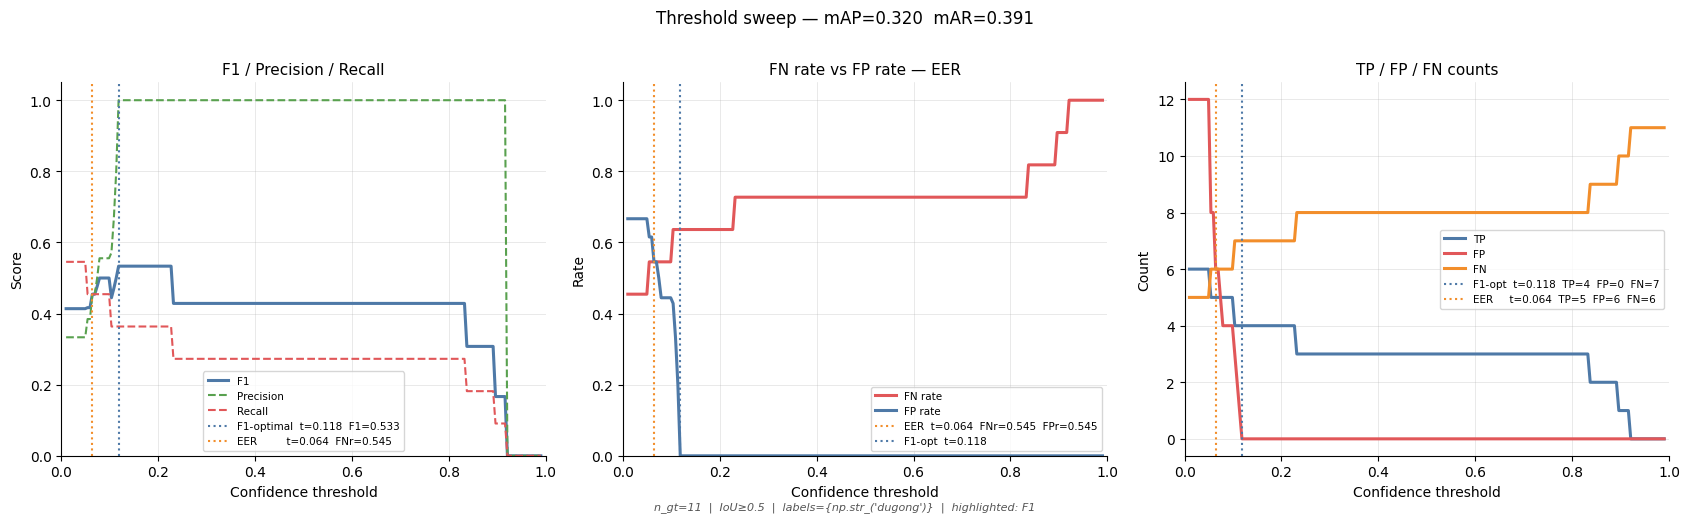

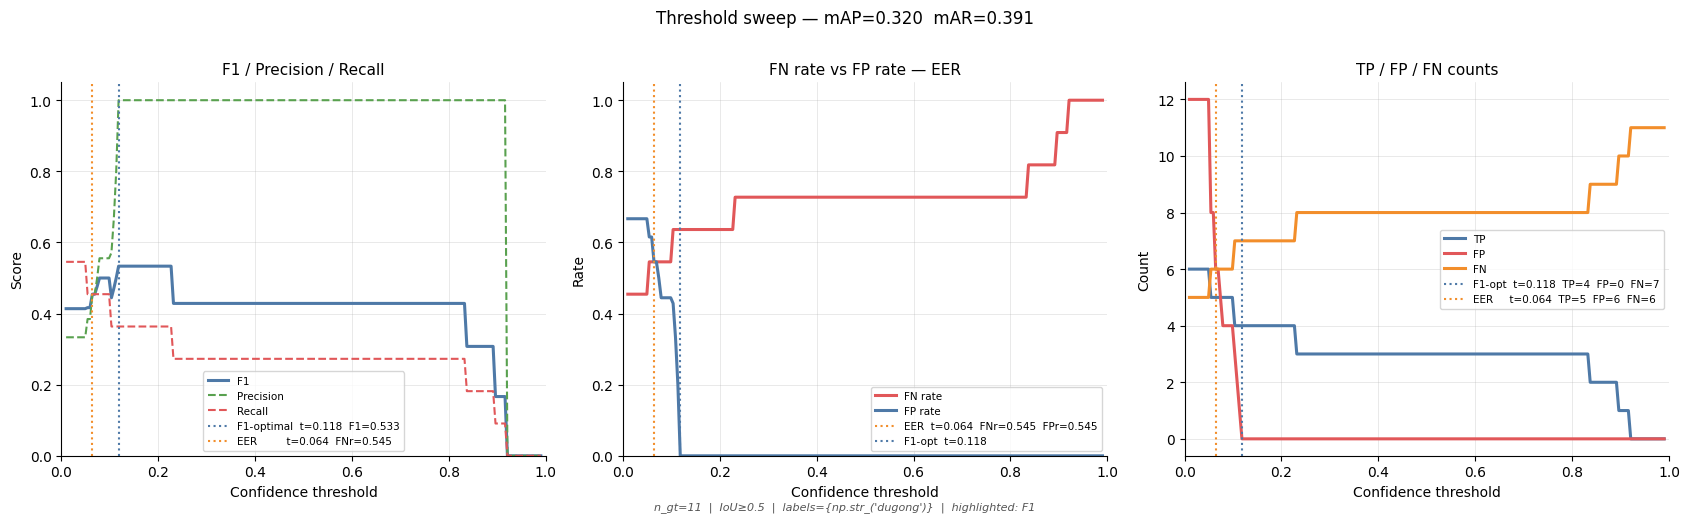

In [52]:
# pick any result to inspect — baseline is a good reference
res = results_seed["baseline_seed2_nms"]

# quick 3-panel diagnostic — shows F1 curve, EER curve, TP/FP/FN counts
# both F1-optimal and EER operating points are marked so you can compare visually
plot_sweep(res, method='f1')

# Analyse

In [42]:
# Restart kernel first, then:
from src.evaluate import sweep_thresholds, plot_sweep, extract_all_metrics

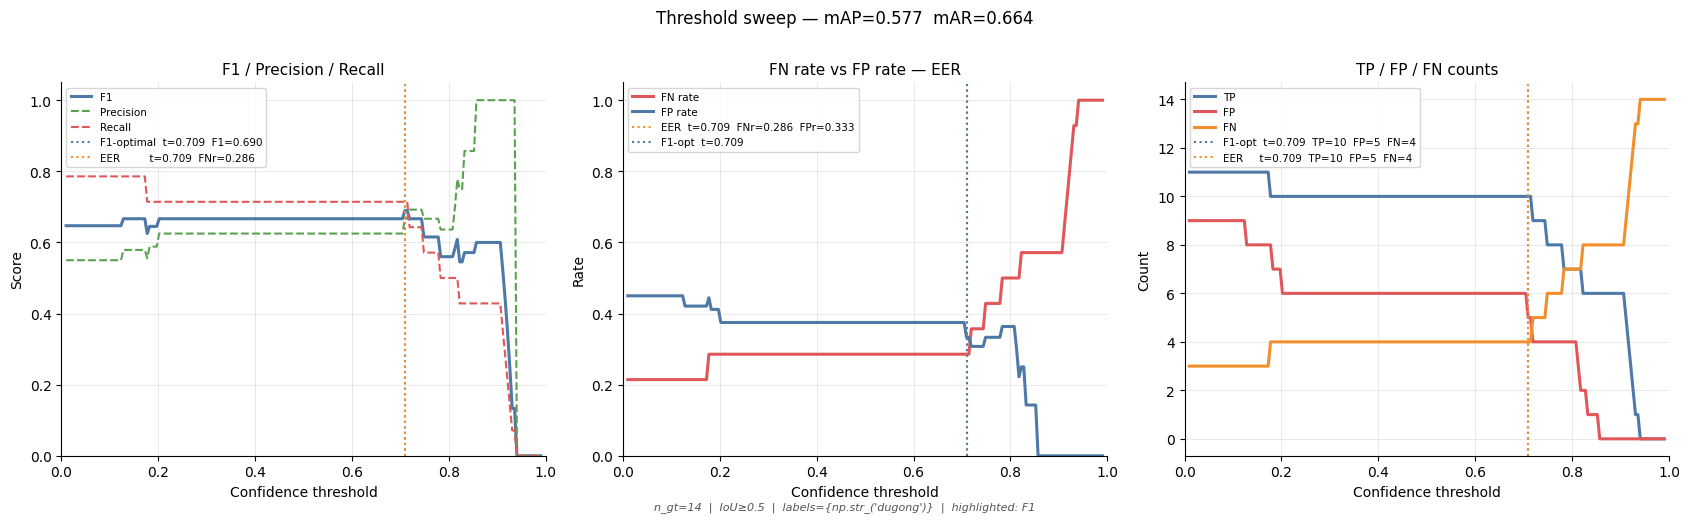

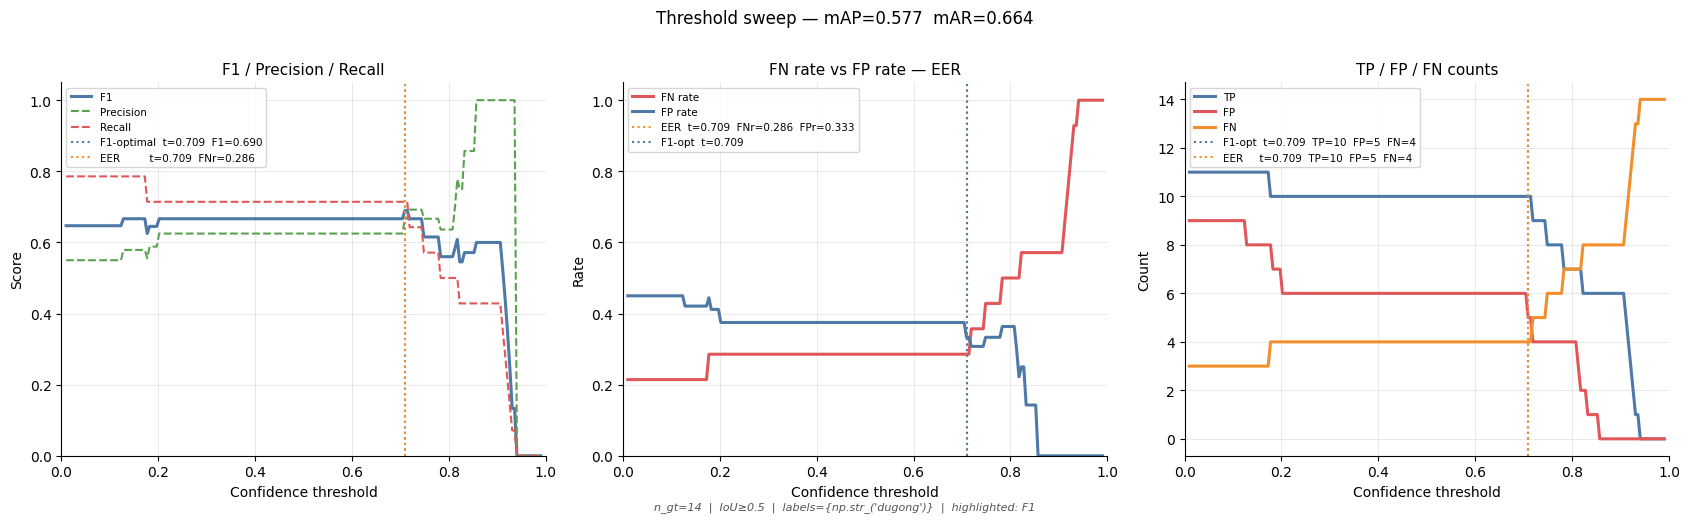

In [15]:
# pick any result to inspect — baseline is a good reference
res = results_seed0["baseline_seed0_nms"]

# quick 3-panel diagnostic — shows F1 curve, EER curve, TP/FP/FN counts
# both F1-optimal and EER operating points are marked so you can compare visually
plot_sweep(res, method='f1')

In [53]:

# compute df
df_seed = extract_all_metrics(
    results_dict = results_seed,
    seed         = 2,
    method       = "f1",       # or "f1" — chosen after inspecting plot_sweep above
    # iou_thresh = None         # reads from res.config.iou automatically
)

# DataFrame columns produced:
# seed, eval_key, mAP, mAR,
# f1_threshold, f1, precision_f1, recall_f1, tp_f1, fp_f1, fn_f1,
# eer_threshold, fn_rate_eer, fp_rate_eer, precision_eer, recall_eer,
# tp_eer, fp_eer, fn_eer,
# n_gt
#
# "threshold", "f1", "precision", "recall", "tp", "fp", "fn"
# are aliases pointing to whichever method was chosen via the method= argument
# so existing plotting functions that read those column names continue to work
# without any changes

df_seed.head()


Seed 2 done — 15 / 15 models processed (method='f1')


,seed,eval_key,mAP,mAR,f1_threshold,f1,precision_f1,recall_f1,tp_f1,fp_f1,...,n_gt,iou_thresh,positive_label,threshold,f1_score,precision,recall,tp,fp,fn
0,2,aclr_p100_seed2_nms,0.574889,0.627273,0.689598,0.842105,1.000000,0.727273,8,0,...,11,0.5,[np.str_('dugong')],0.689598,0.842105,1.000000,0.727273,8,0,3
1,2,random_p100_seed2_nms,0.596912,0.663636,0.389196,0.842105,1.000000,0.727273,8,0,...,11,0.5,[np.str_('dugong')],0.389196,0.842105,1.000000,0.727273,8,0,3
2,2,aclr_p10_seed2_nms,0.524604,0.554545,0.083869,0.761905,0.800000,0.727273,8,2,...,11,0.5,[np.str_('dugong')],0.083869,0.761905,0.800000,0.727273,8,2,3
3,2,random_p10_seed2_nms,0.559010,0.618182,0.280854,0.800000,0.888889,0.727273,8,1,...,11,0.5,[np.str_('dugong')],0.280854,0.800000,0.888889,0.727273,8,1,3
4,2,aclr_p20_seed2_nms,0.515693,0.554545,0.876734,0.842105,1.000000,0.727273,8,0,...,11,0.5,[np.str_('dugong')],0.876734,0.842105,1.000000,0.727273,8,0,3


In [54]:
## save metric 
roott_folder = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/studies/evaluation_metrics"

name = "seed2_aclratio_random.parquet"

df_seed.to_parquet(os.path.join(roott_folder,name))

In [77]:
from src.plot_evaluation import (
        plot_pr_curves_partitions,
        plot_confidence_grid,
        plot_f1_vs_partition,
        plot_relative_improvement,
        plot_efficiency_curves,
    )

In [55]:
import pandas as pd
#  reload dataset
df_seed0_p = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/studies/evaluation_metrics/seed0_aclratio_random.parquet"
df_seed1_p = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/studies/evaluation_metrics/seed1_aclratio_random.parquet"
df_seed2_p = "/share/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/studies/evaluation_metrics/seed2_aclratio_random.parquet"

df_seed_0 = pd.read_parquet(df_seed0_p)
df_seed_1 = pd.read_parquet(df_seed1_p)
df_seed_2 = pd.read_parquet(df_seed2_p)

In [63]:
# In the notebook — check what was imported
from src import plot_evaluation
print(type(plot_evaluation.plot_f1_vs_partition))
print(plot_evaluation.__file__)

<class 'function'>
/share/castor/home/e2406743/code/Dugongs_IRISA-MARBEC-LIRMM/chapter2_FLPLAN/src/plot_evaluation.py


In [65]:
df_seed_0.shape

(15, 29)

In [ ]:
df_seed_0['seed']=['s0' for x in range(df_seed_0.shape[0])]
df_seed_1['seed']=['s1' for x in range(df_seed_1.shape[0])]
df_seed_2['seed']=['s2' for x in range(df_seed_2.shape[0])]

df_concat = pd.concat([df_seed_0, df_seed_1, df_seed_2], axis=0)
df_concat.shape

df_concat['method'] = df_concat['eval_key'].apply(lambda x:x.split('_')[0])
df_concat['partition'] = df_concat['eval_key'].apply(lambda x:x.split('_')[1])

In [76]:
df_concat

,seed,eval_key,mAP,mAR,f1_threshold,f1,precision_f1,recall_f1,tp_f1,fp_f1,...,positive_label,threshold,f1_score,precision,recall,tp,fp,fn,method,partition
0,s0,aclr_p40_seed0_nms,0.740619,0.778571,0.930905,0.833333,1.000000,0.714286,10,0,...,[np.str_('dugong')],0.930905,0.833333,1.000000,0.714286,10,0,4,aclr,p40
1,s0,random_p40_seed0_nms,0.737654,0.778571,0.950603,0.857143,0.857143,0.857143,12,2,...,[np.str_('dugong')],0.950603,0.857143,0.857143,0.857143,12,2,2,random,p40
2,s0,random_p50_seed0_nms,0.762525,0.800000,0.162663,0.866667,0.812500,0.928571,13,3,...,[np.str_('dugong')],0.162663,0.866667,0.812500,0.928571,13,3,1,random,p50
3,s0,aclr_p10_seed0_nms,0.743795,0.757143,0.861960,0.923077,1.000000,0.857143,12,0,...,[np.str_('dugong')],0.861960,0.923077,1.000000,0.857143,12,0,2,aclr,p10
4,s0,random_p5_seed0_nms,0.584933,0.628571,0.911206,0.740741,0.769231,0.714286,10,3,...,[np.str_('dugong')],0.911206,0.740741,0.769231,0.714286,10,3,4,random,p5
5,s0,aclr_p100_seed0_nms,0.740173,0.771429,0.812714,0.923077,1.000000,0.857143,12,0,...,[np.str_('dugong')],0.812714,0.923077,1.000000,0.857143,12,0,2,aclr,p100
6,s0,aclr_p5_seed0_nms,0.667694,0.728571,0.965377,0.880000,1.000000,0.785714,11,0,...,[np.str_('dugong')],0.965377,0.880000,1.000000,0.785714,11,0,3,aclr,p5
7,s0,random_p20_seed0_nms,0.728861,0.757143,0.955528,0.888889,0.923077,0.857143,12,1,...,[np.str_('dugong')],0.955528,0.888889,0.923077,0.857143,12,1,2,random,p20
8,s0,random_p30_seed0_nms,0.724022,0.771429,0.930905,0.814815,0.846154,0.785714,11,2,...,[np.str_('dugong')],0.930905,0.814815,0.846154,0.785714,11,2,3,random,p30
9,s0,random_p10_seed0_nms,0.705077,0.735714,0.950603,0.846154,0.916667,0.785714,11,1,...,[np.str_('dugong')],0.950603,0.846154,0.916667,0.785714,11,1,3,random,p10


  Seeds found     : ['s0', 's1', 's2']
  Baseline anchors:
    seed=s0  anchor=0.6897
    seed=s1  anchor=0.4762
    seed=s2  anchor=0.5333


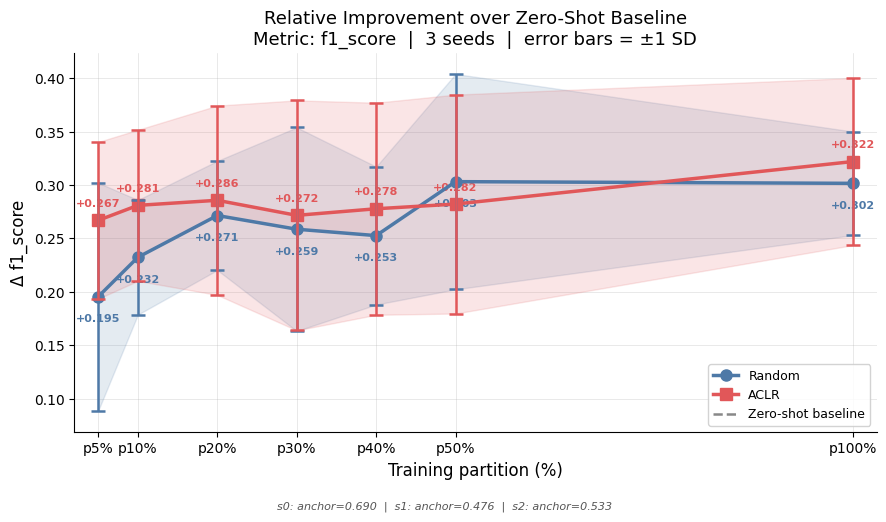

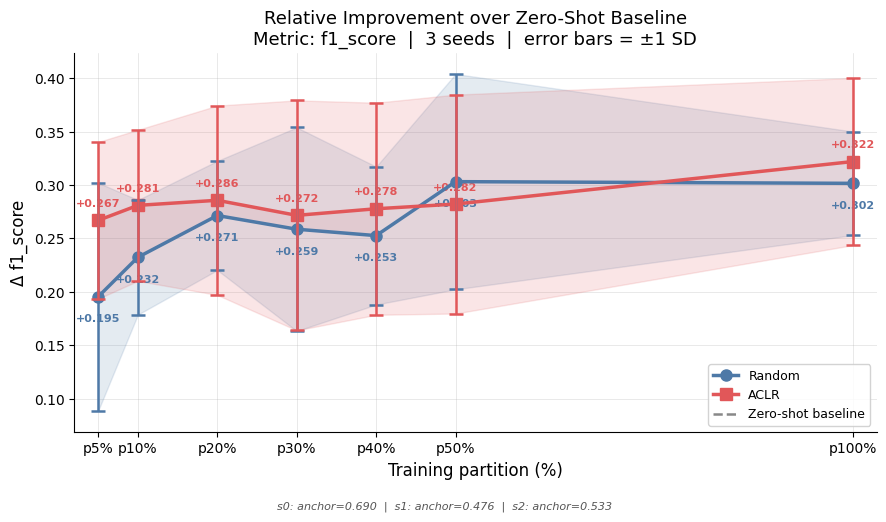

In [ ]:
fig = plot_relative_improvement(df_concat = df_concat,
                           partitions = ["p5", "p10", "p20", "p30", "p40", "p50", "p100"])

In [80]:
df_concat

,seed,eval_key,mAP,mAR,f1_threshold,f1,precision_f1,recall_f1,tp_f1,fp_f1,...,positive_label,threshold,f1_score,precision,recall,tp,fp,fn,method,partition
0,s0,aclr_p40_seed0_nms,0.740619,0.778571,0.930905,0.833333,1.000000,0.714286,10,0,...,[np.str_('dugong')],0.930905,0.833333,1.000000,0.714286,10,0,4,aclr,p40
1,s0,random_p40_seed0_nms,0.737654,0.778571,0.950603,0.857143,0.857143,0.857143,12,2,...,[np.str_('dugong')],0.950603,0.857143,0.857143,0.857143,12,2,2,random,p40
2,s0,random_p50_seed0_nms,0.762525,0.800000,0.162663,0.866667,0.812500,0.928571,13,3,...,[np.str_('dugong')],0.162663,0.866667,0.812500,0.928571,13,3,1,random,p50
3,s0,aclr_p10_seed0_nms,0.743795,0.757143,0.861960,0.923077,1.000000,0.857143,12,0,...,[np.str_('dugong')],0.861960,0.923077,1.000000,0.857143,12,0,2,aclr,p10
4,s0,random_p5_seed0_nms,0.584933,0.628571,0.911206,0.740741,0.769231,0.714286,10,3,...,[np.str_('dugong')],0.911206,0.740741,0.769231,0.714286,10,3,4,random,p5
5,s0,aclr_p100_seed0_nms,0.740173,0.771429,0.812714,0.923077,1.000000,0.857143,12,0,...,[np.str_('dugong')],0.812714,0.923077,1.000000,0.857143,12,0,2,aclr,p100
6,s0,aclr_p5_seed0_nms,0.667694,0.728571,0.965377,0.880000,1.000000,0.785714,11,0,...,[np.str_('dugong')],0.965377,0.880000,1.000000,0.785714,11,0,3,aclr,p5
7,s0,random_p20_seed0_nms,0.728861,0.757143,0.955528,0.888889,0.923077,0.857143,12,1,...,[np.str_('dugong')],0.955528,0.888889,0.923077,0.857143,12,1,2,random,p20
8,s0,random_p30_seed0_nms,0.724022,0.771429,0.930905,0.814815,0.846154,0.785714,11,2,...,[np.str_('dugong')],0.930905,0.814815,0.846154,0.785714,11,2,3,random,p30
9,s0,random_p10_seed0_nms,0.705077,0.735714,0.950603,0.846154,0.916667,0.785714,11,1,...,[np.str_('dugong')],0.950603,0.846154,0.916667,0.785714,11,1,3,random,p10


<Axes: xlabel='partition', ylabel='mAP'>

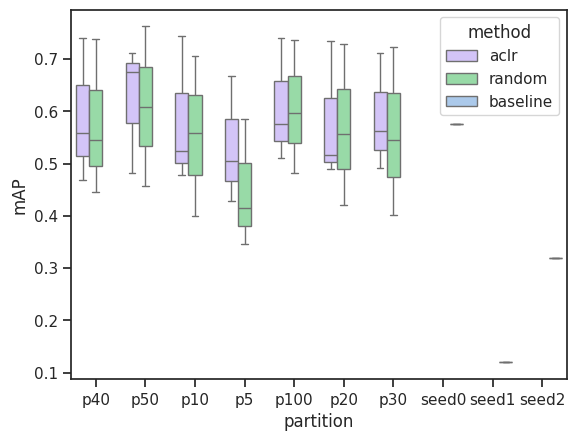

In [81]:
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel")


# Draw a nested boxplot to show bills by day and time
sns.boxplot(x="partition", y="mAP",
            hue="method", palette=["m", "g","b"],
            data=df_concat)
#sns.despine(offset=10, trim=True)

In [83]:
plot_box_strip(
    df_concat = df_concat,
    metrics = ['mAP','mAR']
)

NameError: name '_normalise_partitions' is not defined

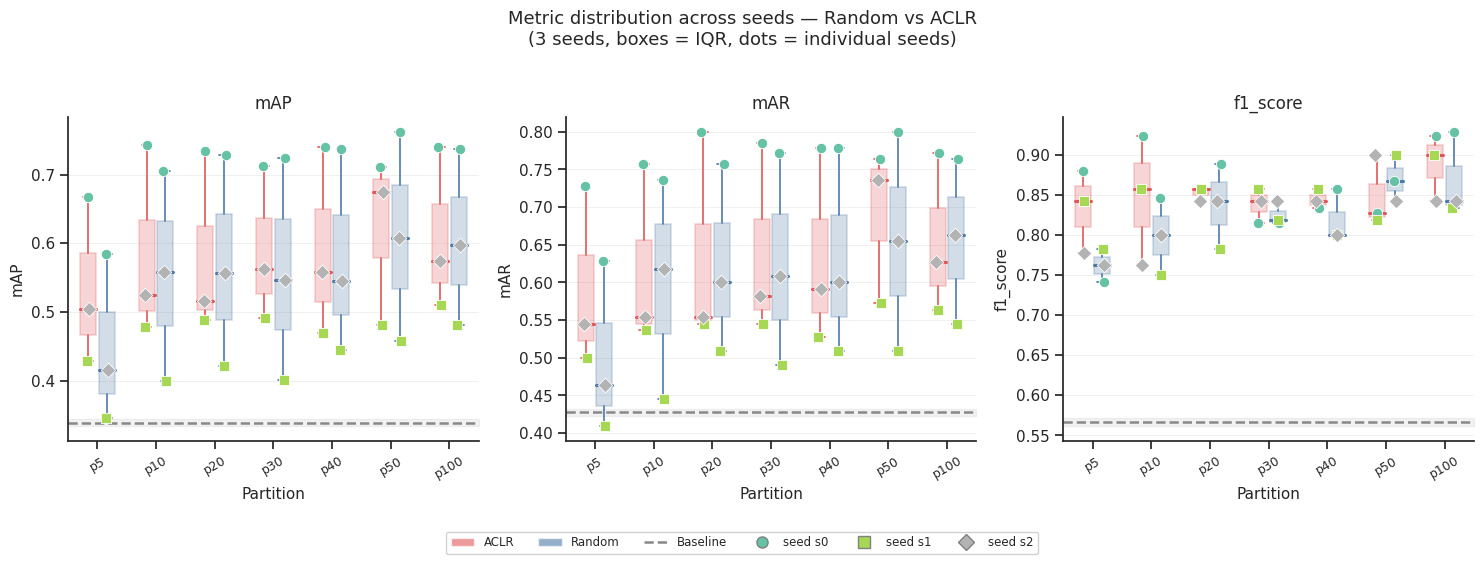

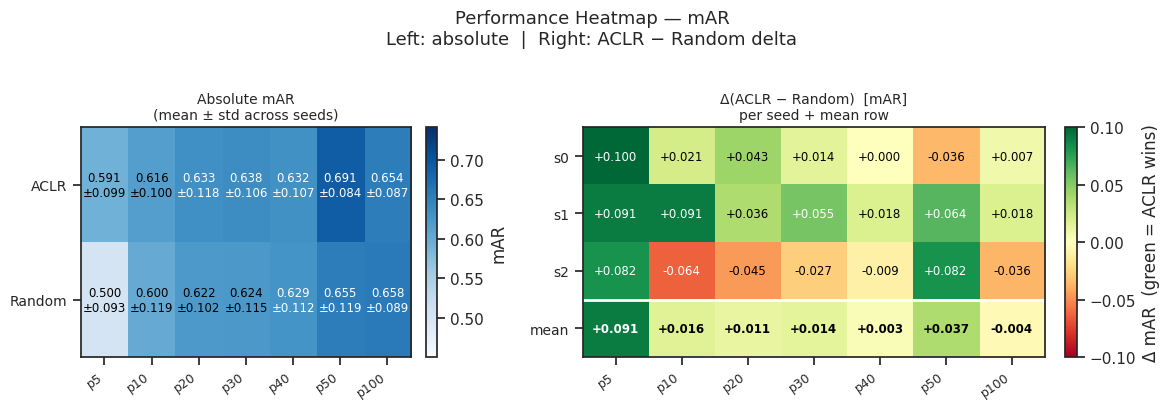

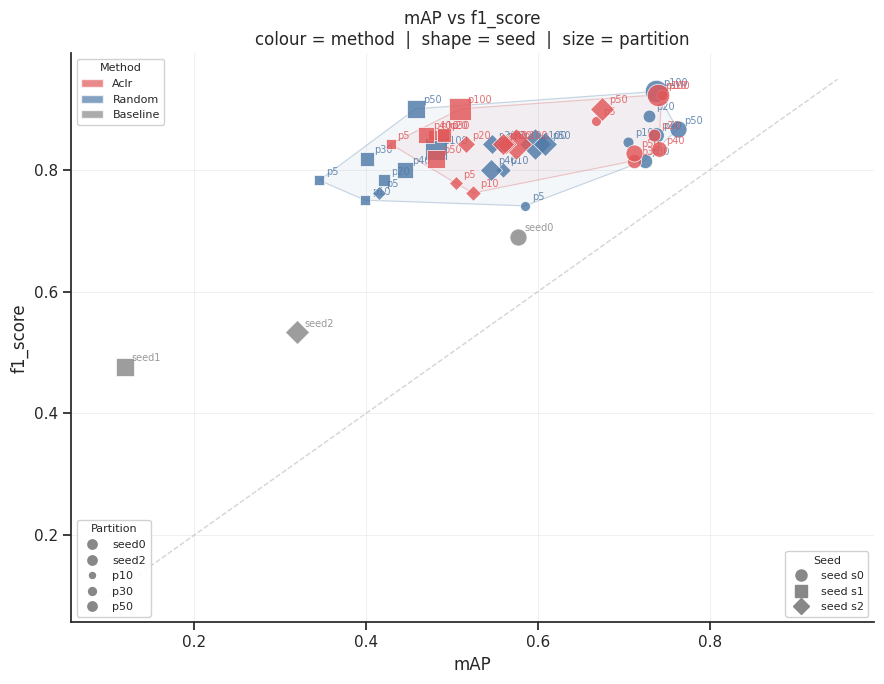

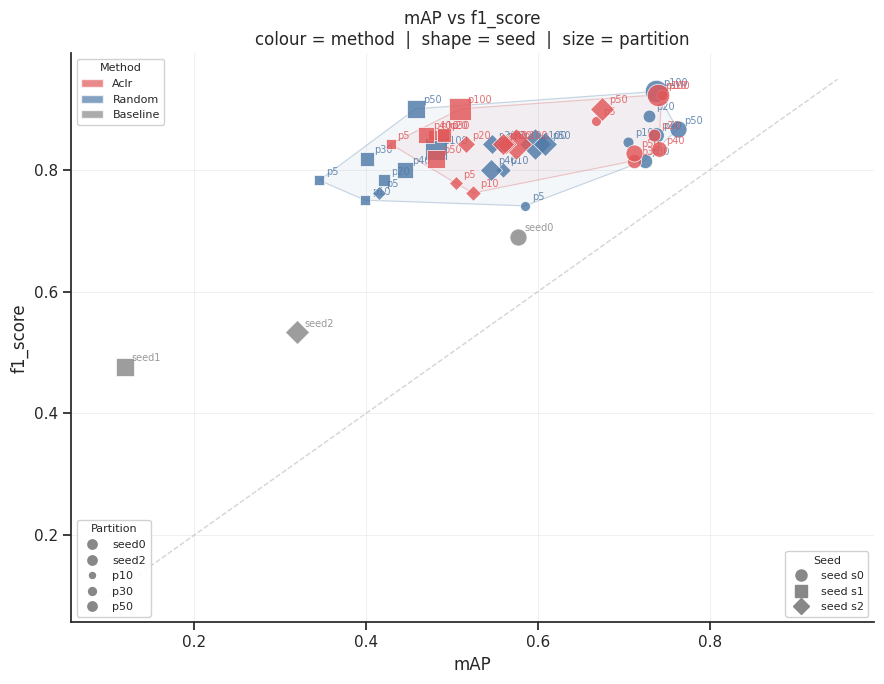

In [86]:
from src.plot_analysis import (
    plot_box_strip,
    plot_delta_heatmap,
    plot_map_vs_f1,
)

# Plot 1 — box + strip, two metrics side by side
plot_box_strip(df_concat, metrics=["mAP","mAR", "f1_score"])

# Plot 2 — delta heatmap for f1_score
plot_delta_heatmap(df_concat, metric="mAR")

# Plot 3 — mAP vs F1 scatter
plot_map_vs_f1(df_concat)

In [10]:
def plot_cluster_distribution_grid(
    dataset,
    cluster_field: str   = "cluster_label",
    seeds:         list  = [0, 1, 2],
    figsize:       tuple = (14, 10),
    title:         str   = None,
    save_path:     str   = None,
) -> "plt.Figure":
    """
    3×3 grid showing count of images per cluster label for each
    seed × split combination.

    Rows    : seeds  (seed0, seed1, seed2)
    Columns : splits (train, val, test)

    Parameters
    ----------
    dataset       : FiftyOne dataset
    cluster_field : field containing cluster labels
    seeds         : list of seed indices, default [0, 1, 2]
    figsize       : figure size
    title         : figure suptitle
    save_path     : optional save path stem (.png + .pdf)
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches

    splits = ["train", "val", "test"]

    # ── Discover all cluster labels across the full dataset ───────────────────
    raw_distinct = dataset.distinct(cluster_field)
    raw_distinct = [v for v in raw_distinct if v is not None]

    # handle both string ("cluster_0") and numeric (0, 0.0) storage
    def _cluster_sort_key(v):
        s = str(v)
        # extract trailing integer for sorting: "cluster_0" → 0, "0" → 0
        digits = "".join(c for c in s.split("_")[-1] if c.isdigit())
        return int(digits) if digits else s

    all_clusters  = sorted(raw_distinct, key=_cluster_sort_key)
    n_clusters    = len(all_clusters)
    cluster_index = {str(c): i for i, c in enumerate(all_clusters)}

    palette       = plt.cm.tab10(np.linspace(0, 1, max(n_clusters, 1)))
    cluster_color = {str(c): palette[i % len(palette)]
                     for i, c in enumerate(all_clusters)}

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        len(seeds), len(splits),
        figsize=figsize,
        sharey=False,
        sharex=True,
    )
    fig.patch.set_facecolor("white")

    x_pos = np.arange(n_clusters)

    for row_idx, seed in enumerate(seeds):
        for col_idx, split in enumerate(splits):
            ax  = axes[row_idx, col_idx]
            tag = f"{split}_{seed}"

            view      = dataset.match_tags(tag)
            n_samples = len(view)

            if n_samples == 0:
                ax.text(
                    0.5, 0.5,
                    f"no samples\n(tag: {tag})",
                    transform=ax.transAxes,
                    ha="center", va="center",
                    fontsize=9, color="#888780", style="italic",
                )
                ax.set_title(
                    f"{split.capitalize()} | seed {seed}  (n=0)",
                    fontsize=9,
                )
                ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)
                ax.spines[["top", "right"]].set_visible(False)
                continue

            counts_raw = view.count_values(cluster_field)

            # align counts to the global cluster list
            counts = np.array([
                counts_raw.get(c, counts_raw.get(str(c), 0))
                for c in all_clusters
            ])
            colors = [cluster_color[str(c)] for c in all_clusters]

            bars = ax.bar(
                x_pos, counts,
                color=colors,
                edgecolor="white",
                linewidth=0.5,
                width=0.75,
            )

            # count label above each bar
            max_count = max(counts) if counts.max() > 0 else 1
            for bar, count in zip(bars, counts):
                if count > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max_count * 0.015,
                        str(int(count)),
                        ha="center", va="bottom",
                        fontsize=7, color="#333333",
                    )

            ax.set_title(
                f"{split.capitalize()} | seed {seed}  (n={n_samples})",
                fontsize=9, fontweight="500",
            )
            ax.set_xticks(x_pos)
            ax.set_xticklabels(
                [str(c) for c in all_clusters],
                fontsize=8, rotation=30, ha="right",
            )
            ax.set_ylim(0, max_count * 1.20)
            ax.grid(True, axis="y", linewidth=0.4, alpha=0.5)
            ax.spines[["top", "right"]].set_visible(False)

        # row label on the leftmost axis
        axes[row_idx, 0].set_ylabel(f"seed {seed}\n\nCount", fontsize=9)

    # x-axis label on bottom row only
    for ax in axes[-1]:
        ax.set_xlabel("Cluster label", fontsize=9)

    # ── Shared colour legend ──────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=cluster_color[str(c)], label=str(c))
        for c in all_clusters
    ]
    fig.legend(
        handles        = legend_handles,
        title          = "Cluster label",
        title_fontsize = 8,
        fontsize       = 7.5,
        loc            = "lower center",
        ncol           = min(n_clusters, 10),
        frameon        = True,
        framealpha     = 0.9,
        bbox_to_anchor = (0.5, -0.04),
    )

    _title = title or (
        "Image count per cluster label\n"
        "Rows = seeds  |  Columns = train / val / test"
    )
    fig.suptitle(_title, fontsize=13, fontweight="500", y=1.02)
    plt.tight_layout()

    if save_path:
        fig.savefig(f"{save_path}.png", dpi=300, bbox_inches="tight")
        fig.savefig(f"{save_path}.pdf", dpi=300, bbox_inches="tight")
        print(f"  Saved → {save_path}.png / .pdf")

    plt.show()
    return fig

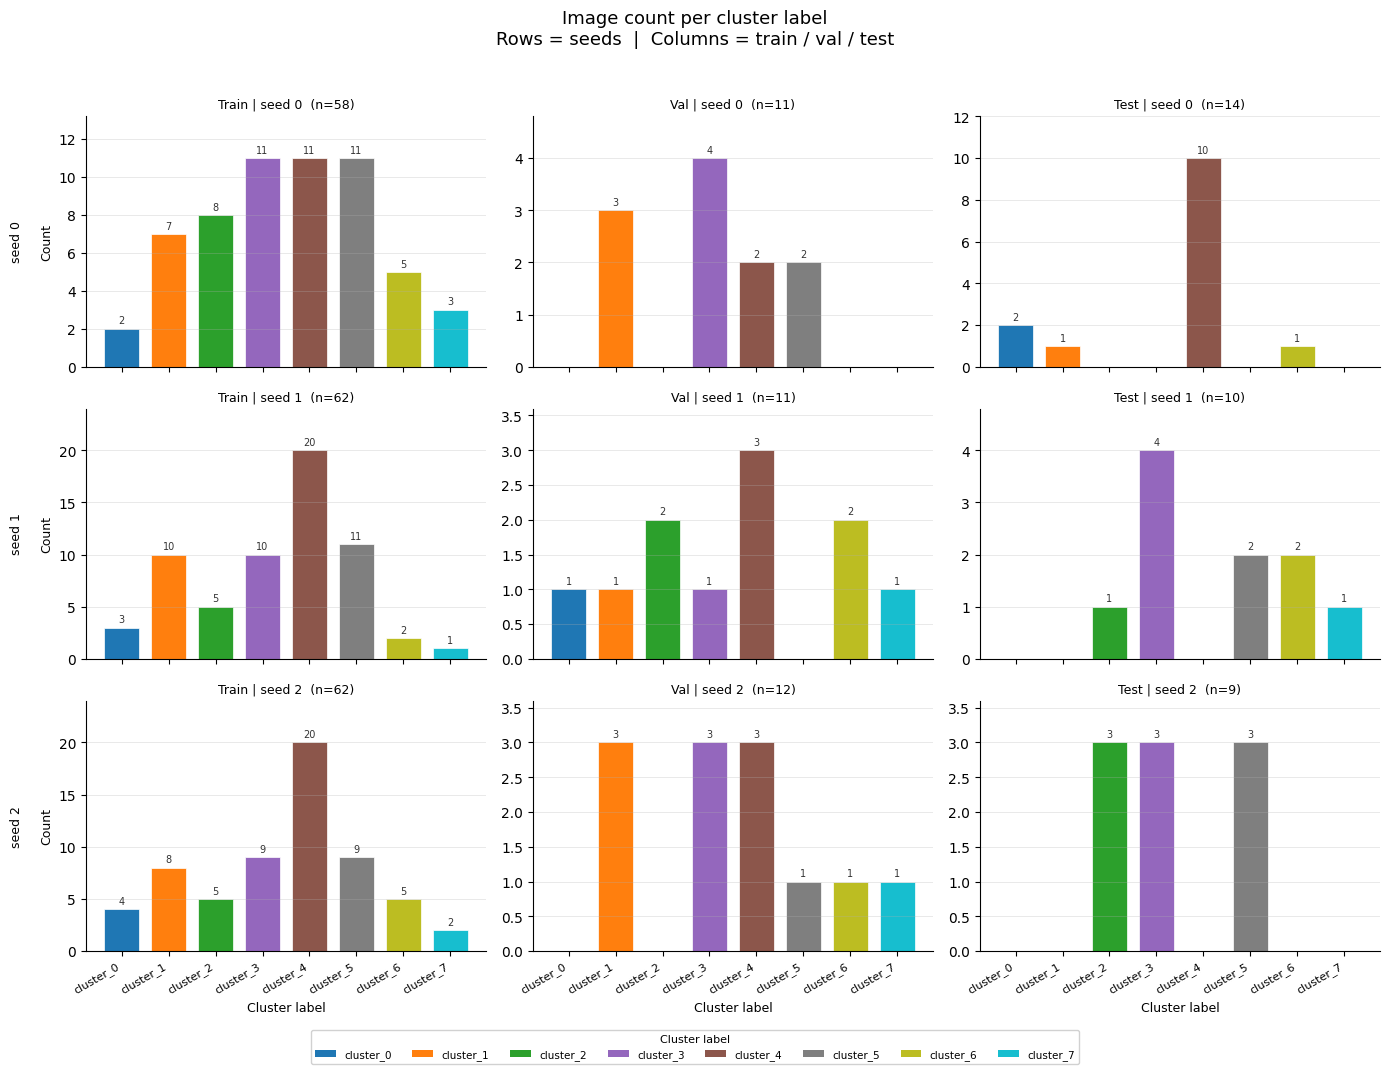

In [12]:
fig = plot_cluster_distribution_grid(
    dataset= dataset,
    cluster_field="cluster_label_8"
)

In [13]:
dataset.list_evaluations()

['aclr_p100_seed0_nms',
 'aclr_p100_seed1_nms',
 'aclr_p100_seed2_nms',
 'aclr_p10_seed0_nms',
 'aclr_p10_seed1_nms',
 'aclr_p10_seed2_nms',
 'aclr_p20_seed0_nms',
 'aclr_p20_seed1_nms',
 'aclr_p20_seed2_nms',
 'aclr_p30_seed0_nms',
 'aclr_p30_seed1_nms',
 'aclr_p30_seed2_nms',
 'aclr_p40_seed0_nms',
 'aclr_p40_seed1_nms',
 'aclr_p40_seed2_nms',
 'aclr_p50_seed0_nms',
 'aclr_p50_seed1_nms',
 'aclr_p50_seed2_nms',
 'aclr_p5_seed0_nms',
 'aclr_p5_seed1_nms',
 'aclr_p5_seed2_nms',
 'baseline_seed0_nms',
 'baseline_seed1_nms',
 'baseline_seed2_nms',
 'new_baseline_seed0_nms',
 'random_p100_seed0_nms',
 'random_p100_seed1_nms',
 'random_p100_seed2_nms',
 'random_p10_seed0_nms',
 'random_p10_seed1_nms',
 'random_p10_seed2_nms',
 'random_p20_seed0_nms',
 'random_p20_seed1_nms',
 'random_p20_seed2_nms',
 'random_p30_seed0_nms',
 'random_p30_seed1_nms',
 'random_p30_seed2_nms',
 'random_p40_seed0_nms',
 'random_p40_seed1_nms',
 'random_p40_seed2_nms',
 'random_p50_seed0_nms',
 'random_p50_seed1

In [17]:
from fiftyone import ViewField as F
# view of all samples that have at least one FN
fn_view = dataset.match(F(f"aclr_p5_seed1_nms_fn") > 0)
fn_view.values("cluster_label_8")

['cluster_3', 'cluster_5']

In [ ]:
# view of all samples that have at least one FN
fn_view = dataset.match(F(f"aclr_p10_seed0_nms_fn") > 0)
fn_view.values("cluster_label_8")

['cluster_4', 'cluster_4']

In [ ]:
# view of all samples that have at least one FN
fn_view = dataset.match(F(f"random_p100_seed1_nms_fn") > 0)
fn_view.values("cluster_label_8")

['cluster_4']

In [21]:
# view of all samples that have at least one FN
fn_view = dataset.match(F(f"random_p100_seed1_nms_fn") > 0)
fn_view.values("cluster_label_8")

['cluster_5']

In [24]:
# view of all samples that have at least one FN
fn_view = dataset.match(F(f"random_p100_seed2_nms_fn") > 0)
fn_view.values("cluster_label_8")

['cluster_3', 'cluster_3']

In [25]:
session.view = fn_view